# Financial Data Extraction & Initial Analysis

**Objective:** Analyze 2023–2025 financial data for Microsoft, Tesla, and Apple using pandas. All monetary values are **USD millions**.

Fiscal year-end dates differ: Microsoft ends June 30, Apple ends in late September, and Tesla ends December 31.

## 1. Load the data

Keep `financial_data.csv` in the same folder as this notebook.

In [14]:
import pandas as pd

microsoft = pd.read_csv('microsoft_financial_data.csv')
tesla = pd.read_csv('tesla_financial_data.csv')
apple = pd.read_csv('apple_financial_data.csv')

df = pd.concat([microsoft, tesla, apple], ignore_index=True)

df

,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operating Activities
0,Microsoft,2023,211915,72361,411976,205753,87582
1,Microsoft,2024,245122,88136,512163,243686,118548
2,Microsoft,2025,281724,101832,619003,275524,136162
3,Tesla,2023,96773,14974,106618,43009,13256
4,Tesla,2024,97690,7153,122070,48390,14923
5,Tesla,2025,94827,3855,137806,54941,14747
6,Apple,2023,383285,96995,352583,290437,110543
7,Apple,2024,391035,93736,364980,308030,118254
8,Apple,2025,416161,112010,359241,285508,111482


## 2. Check the dataset


In [15]:
print('Rows and columns:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

Rows and columns: (9, 7)

Missing values:
Company                                0
Year                                   0
Total Revenue                          0
Net Income                             0
Total Assets                           0
Total Liabilities                      0
Cash Flow from Operating Activities    0
dtype: int64

Data types:
Company                                  str
Year                                   int64
Total Revenue                          int64
Net Income                             int64
Total Assets                           int64
Total Liabilities                      int64
Cash Flow from Operating Activities    int64
dtype: object


## 3. Calculate year-over-year growth

`groupby()` makes the comparison separately for each company.

In [16]:
metrics = ['Total Revenue','Net Income','Total Assets','Total Liabilities','Cash Flow from Operating Activities']

for metric in metrics:
    df[f'{metric} Growth (%)'] = df.groupby('Company')[metric].pct_change() * 100

df.round(2)

,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operating Activities,Total Revenue Growth (%),Net Income Growth (%),Total Assets Growth (%),Total Liabilities Growth (%),Cash Flow from Operating Activities Growth (%)
0,Microsoft,2023,211915,72361,411976,205753,87582,NaN,NaN,NaN,NaN,NaN
1,Microsoft,2024,245122,88136,512163,243686,118548,15.67,21.80,24.32,18.44,35.36
2,Microsoft,2025,281724,101832,619003,275524,136162,14.93,15.54,20.86,13.07,14.86
3,Tesla,2023,96773,14974,106618,43009,13256,NaN,NaN,NaN,NaN,NaN
4,Tesla,2024,97690,7153,122070,48390,14923,0.95,-52.23,14.49,12.51,12.58
5,Tesla,2025,94827,3855,137806,54941,14747,-2.93,-46.11,12.89,13.54,-1.18
6,Apple,2023,383285,96995,352583,290437,110543,NaN,NaN,NaN,NaN,NaN
7,Apple,2024,391035,93736,364980,308030,118254,2.02,-3.36,3.52,6.06,6.98
8,Apple,2025,416161,112010,359241,285508,111482,6.43,19.50,-1.57,-7.31,-5.73


## 4. Profit margin


In [17]:
df['Net Profit Margin (%)'] = df['Net Income'] / df['Total Revenue'] * 100
df[['Company','Year','Total Revenue','Net Income','Net Profit Margin (%)']].round(2)

,Company,Year,Total Revenue,Net Income,Net Profit Margin (%)
0,Microsoft,2023,211915,72361,34.15
1,Microsoft,2024,245122,88136,35.96
2,Microsoft,2025,281724,101832,36.15
3,Tesla,2023,96773,14974,15.47
4,Tesla,2024,97690,7153,7.32
5,Tesla,2025,94827,3855,4.07
6,Apple,2023,383285,96995,25.31
7,Apple,2024,391035,93736,23.97
8,Apple,2025,416161,112010,26.92


## 5. Compare companies by year


In [18]:
for year in sorted(df['Year'].unique()):
    print(f'\n===== {year} =====')
    display(df[df['Year']==year][['Company','Total Revenue','Net Income','Total Assets','Total Liabilities','Cash Flow from Operating Activities']])


===== 2023 =====


,Company,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operating Activities
0,Microsoft,211915,72361,411976,205753,87582
3,Tesla,96773,14974,106618,43009,13256
6,Apple,383285,96995,352583,290437,110543



===== 2024 =====


,Company,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operating Activities
1,Microsoft,245122,88136,512163,243686,118548
4,Tesla,97690,7153,122070,48390,14923
7,Apple,391035,93736,364980,308030,118254



===== 2025 =====


,Company,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operating Activities
2,Microsoft,281724,101832,619003,275524,136162
5,Tesla,94827,3855,137806,54941,14747
8,Apple,416161,112010,359241,285508,111482


## 6. Visual analysis

The charts help identify trends in revenue, net income, and operating cash flow.

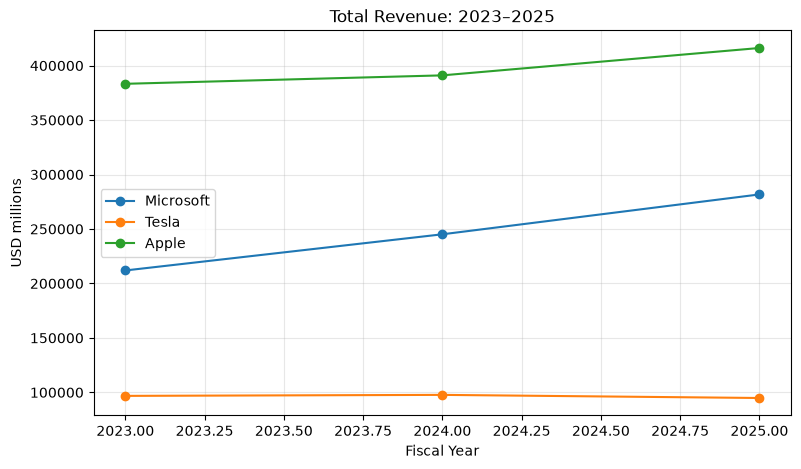

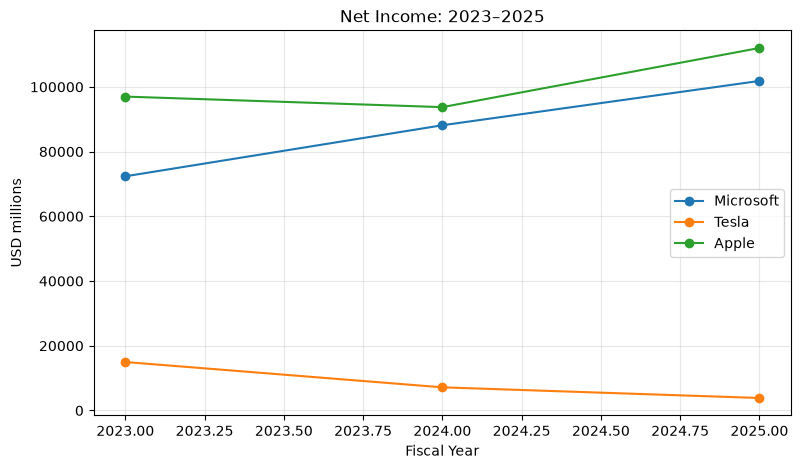

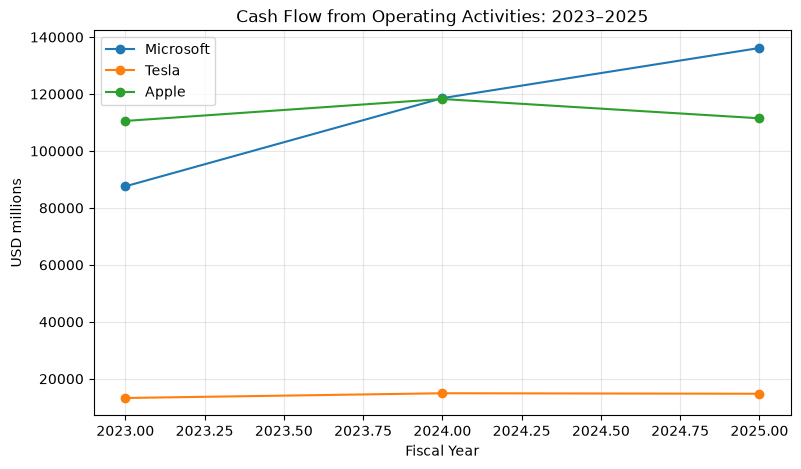

In [19]:
import matplotlib.pyplot as plt

for metric in ['Total Revenue','Net Income','Cash Flow from Operating Activities']:
    plt.figure(figsize=(9,5))
    for company in df['Company'].unique():
        x=df[df['Company']==company]
        plt.plot(x['Year'],x[metric],marker='o',label=company)
    plt.title(f'{metric}: 2023–2025')
    plt.xlabel('Fiscal Year')
    plt.ylabel('USD millions')
    plt.legend()
    plt.grid(True,alpha=0.3)
    plt.show()

# 7. Key Findings

## Microsoft

- Revenue increased from **USD 211.9B in 2023 to USD 281.7B in 2025**.
- Net income increased from **USD 72.4B in 2023 to USD 101.8B in 2025**.
- Operating cash flow increased from **USD 87.6B in 2023 to USD 136.2B in 2025**.
- Net profit margin improved from **34.15% in 2023 to 36.15% in 2025**.

## Tesla

- Revenue was broadly stable, increasing slightly in 2024 before declining in 2025.
- Net income fell sharply from **USD 15.0B in 2023 to USD 3.9B in 2025**.
- Net profit margin declined from **15.47% in 2023 to 4.07% in 2025**.
- Operating cash flow remained positive but declined slightly from 2024 to 2025.

## Apple

- Revenue increased from **USD 383.3B in 2023 to USD 416.2B in 2025**.
- Net income increased from **USD 97.0B in 2023 to USD 112.0B in 2025**.
- Net profit margin recovered from **23.97% in 2024 to 26.92% in 2025**.
- Operating cash flow remained strong, although it declined from **USD 118.3B in 2024 to USD 111.5B in 2025**.
- Total liabilities decreased from **USD 308.0B in 2024 to USD 285.5B in 2025**.

## Overall

**Microsoft shows the strongest growth profile, Apple maintains the largest revenue scale and strong profitability, while Tesla shows the clearest deterioration in profitability despite continued growth in total assets.**

# 8. SEC sources

- Microsoft 2025 10-K: https://www.sec.gov/Archives/edgar/data/789019/000095017025100235/msft-20250630.htm
- Microsoft 2024 10-K: https://www.sec.gov/Archives/edgar/data/789019/000095017024087843/msft-20240630.htm
- Microsoft 2023 10-K: https://www.sec.gov/Archives/edgar/data/789019/000095017023035122/msft-20230630.htm

- Tesla 2025 10-K: https://www.sec.gov/Archives/edgar/data/1318605/000162828025003063/tsla-20241231.htm
- Tesla 2024 10-K: https://www.sec.gov/Archives/edgar/data/1318605/000162828024002390/tsla-20231231.htm
- Tesla 2023 10-K: https://www.sec.gov/Archives/edgar/data/1318605/000095017023001409/tsla-20221231.htm

- Apple 2025 10-K: https://www.sec.gov/Archives/edgar/data/320193/000032019325000079/aapl-20250927.htm
- Apple 2024 10-K: https://www.sec.gov/Archives/edgar/data/320193/000032019324000123/aapl-20240928.htm
- Apple 2023 10-K: https://www.sec.gov/Archives/edgar/data/320193/000032019323000106/aapl-20230930.htm